<a href="https://colab.research.google.com/github/farukkilinc1903/group6-innovation-campus-samsung/blob/main/xgboost-randomforest-kar%C5%9F%C4%B1la%C5%9Ft%C4%B1rma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- MODEL PERFORMANS KARŞILAŞTIRMASI ---

[Random Forest] Sonuçları:
   R2 Score (Açıklayıcılık): 0.9165
   MAE (Ortalama Mutlak Hata): 3.23%
   RMSE (Hata Kareler Kökü): 7.52%

[XGBoost] Sonuçları:
   R2 Score (Açıklayıcılık): 0.9524
   MAE (Ortalama Mutlak Hata): 2.18%
   RMSE (Hata Kareler Kökü): 5.68%


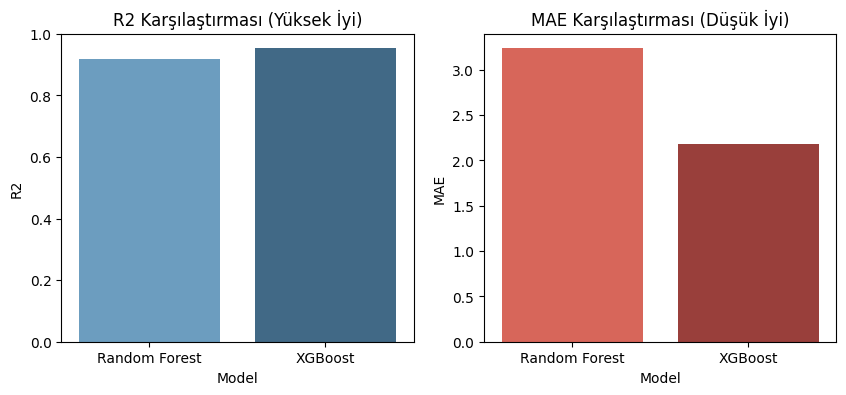

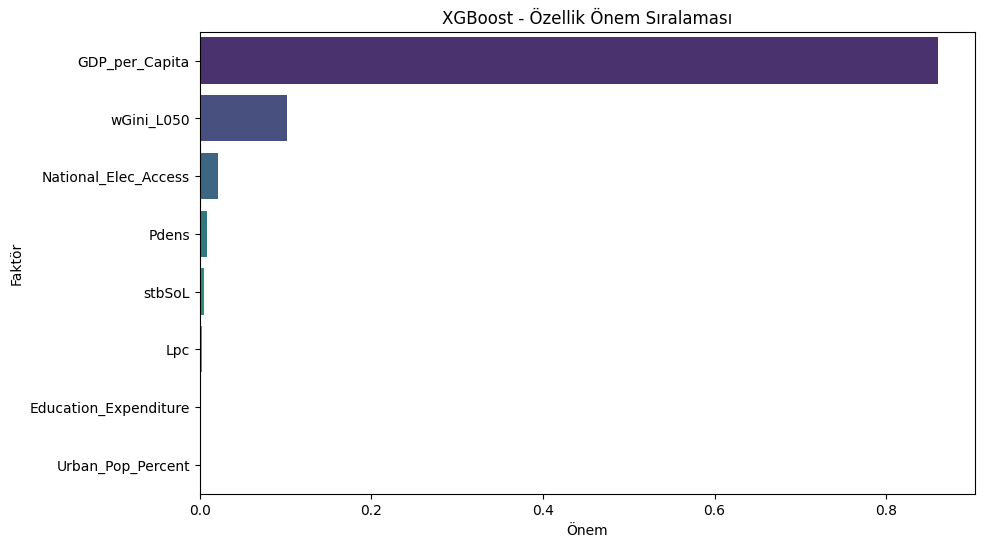

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor # XGBoost eklendi
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# 1. VERİ OKUMA
nasa_df = pd.read_excel('spatialecon-lgii-measures-v1-xlsx.xlsx', sheet_name='Data')
school_df = pd.read_csv('school_electricity_access.csv')

gdp_raw = pd.read_csv('/content/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv', skiprows=4)
nat_elec_raw = pd.read_csv('/content/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_158.csv', skiprows=4)
urban_raw = pd.read_csv('/content/API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_249.csv', skiprows=4)
edu_exp_raw = pd.read_csv('/content/API_SE.XPD.TOTL.GB.ZS_DS2_en_csv_v2_9902.csv', skiprows=4)

# 2. VERİ DÜZENLEME
def format_wb_data(df, value_name):
    years = [str(i) for i in range(1992, 2014)]
    df_melted = df.melt(id_vars=['Country Code'],
                        value_vars=[y for y in years if y in df.columns],
                        var_name='Year',
                        value_name=value_name)
    df_melted['Year'] = df_melted['Year'].astype(int)
    df_melted = df_melted.rename(columns={'Country Code': 'ISO'})
    return df_melted

gdp_df = format_wb_data(gdp_raw, 'GDP_per_Capita')
nat_elec_df = format_wb_data(nat_elec_raw, 'National_Elec_Access')
urban_df = format_wb_data(urban_raw, 'Urban_Pop_Percent')
edu_exp_df = format_wb_data(edu_exp_raw, 'Education_Expenditure')

# 3. VERİ BİRLEŞTİRME
school_df = school_df.rename(columns={'ISO_Code': 'ISO'})

final_df = pd.merge(nasa_df[['ISO', 'Year', 'stbSoL', 'Lpc', 'Pdens', 'wGini_L050']],
                    school_df[['ISO', 'Year', 'Electricity_Access_Percent']],
                    on=['ISO', 'Year'], how='inner')

final_df = pd.merge(final_df, gdp_df, on=['ISO', 'Year'], how='inner')
final_df = pd.merge(final_df, nat_elec_df, on=['ISO', 'Year'], how='inner')
final_df = pd.merge(final_df, urban_df, on=['ISO', 'Year'], how='inner')
final_df = pd.merge(final_df, edu_exp_df, on=['ISO', 'Year'], how='inner')

final_df = final_df.dropna().reset_index(drop=True)

# 4. MAKİNE ÖĞRENMESİ HAZIRLIK
target = 'Electricity_Access_Percent'
# Sayısal olmayan ve hedef değişkeni düşürüyoruz
X = final_df.drop([target, 'ISO', 'Year'], axis=1)
y = final_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. MODELLERİN TANIMLANMASI VE EĞİTİLMESİ
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []

print("--- MODEL PERFORMANS KARŞILAŞTIRMASI ---")

for name, model in models.items():
    # Eğitim
    model.fit(X_train, y_train)
    # Tahmin
    y_pred = model.predict(X_test)

    # Metriklerin Hesaplanması
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse})

    print(f"\n[{name}] Sonuçları:")
    print(f"   R2 Score (Açıklayıcılık): {r2:.4f}")
    print(f"   MAE (Ortalama Mutlak Hata): {mae:.2f}%")
    print(f"   RMSE (Hata Kareler Kökü): {rmse:.2f}%")

# 6. SONUÇLARIN GÖRSELLEŞTİRİLMESİ
results_df = pd.DataFrame(results)

# Performans Metrikleri Tablosu
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.barplot(data=results_df, x='Model', y='R2', hue='Model', palette='Blues_d', legend=False)
plt.title('R2 Karşılaştırması (Yüksek İyi)')

plt.subplot(1, 2, 2)
sns.barplot(data=results_df, x='Model', y='MAE', hue='Model', palette='Reds_d', legend=False)
plt.title('MAE Karşılaştırması (Düşük İyi)')
plt.show()

# 7. XGBOOST ÖZELLİK ÖNEM SIRALAMASI (Feature Importance)

xgb_model = models["XGBoost"]
importances = pd.DataFrame({'Faktör': X.columns, 'Önem': xgb_model.feature_importances_}).sort_values('Önem', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Önem', y='Faktör', hue='Faktör', palette='viridis', legend=False)
plt.title('XGBoost - Özellik Önem Sıralaması')
plt.show()

# Veriyi saklama
final_df.to_csv('final_data_with_education_and_models.csv', index=False)